# Experiment 1.3 — Direct weighted-event coarse temporal binning + linear probe

## Research question

**How much classification information can be recovered from coarse temporal position alone, without a convolutional or recurrent temporal model?**

This experiment complements 1.2. Rather than scrambling block order, it deliberately compresses each valid event sequence into temporal bins. It also adds two 10-bin controls that preserve the 150-D feature size while removing temporal organization.

### Data flow

`action0/action1 combination roots → 15 weighted event channels [T,15] → split valid prefix into N temporal bins → sum each channel inside each bin → flatten [N×15] → linear probe → test metrics`

The one-bin condition is a time-agnostic channel-sum baseline. Increasing the number of bins progressively preserves coarse *when* information while still discarding fine dynamics within each bin.

## Why this is useful

Experiment 1.2 asks how much contiguous local order must be preserved. Experiment 1.3 asks whether simple phase-of-trajectory information (early/middle/late) already explains much of the task. If a small number of bins approaches Event-CNN-L performance, later SNN complexity should be justified carefully; if coarse bins remain weak while 1.2 recovers strongly with local blocks, fine temporal motifs are more important.

## Controls

- Only the valid prefix is binned; right padding contributes exactly zero.
- Bin boundaries are defined independently for each sample using its valid length, so bins represent relative progress through the gesture rather than padded absolute time.
- One deterministic user-disjoint split from `SPLIT_SEED` is reused across all five master seeds and conditions.
- A linear classifier is fitted from scratch for every seed and condition.
- The 10-bin permutation control independently permutes the ten [15]-D bin vectors for each sample before flattening to 150-D.
- The random-grouping control independently permutes valid timesteps for each sample, partitions them into ten balanced groups, and sums 15 channels per group; it also produces 150-D features without temporal adjacency.
- Both controls use deterministic per-sample seeds derived from the master seed and sample ID.
- Primary metric: test balanced accuracy.


In [3]:
from pathlib import Path
import hashlib
import json
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root from current working directory")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Repository root: /home/ted/project/writingring-viz
PyTorch: 2.11.0+cu130
CUDA available: True


## 1. Configuration

In [4]:
# -----------------------------------------------------------------------------
# USER CONFIGURATION
# -----------------------------------------------------------------------------
ACTION0_COMBINATION_DIR = REPO_ROOT / "outputs/action0_wavelets_0e5_1_2_4_8_sr_64"
ACTION1_COMBINATION_DIR = REPO_ROOT / "outputs/action1_wavelets_0e5_1_2_4_8_sr_64"
DATASET_ROOTS = [ACTION0_COMBINATION_DIR, ACTION1_COMBINATION_DIR]
SEEDS = (11, 23, 37, 53, 71)
assert len(SEEDS) == 5 and len(set(SEEDS)) == 5
# Fixed user-split seed shared across Experiments 1.1–1.3.
SPLIT_SEED: int = 12345
# Ordered labels to retain after user exclusion; None keeps every label.
INCLUDED_LABELS: tuple[str, ...] | None = ("A", "B", "C", "D", "E", "X", "G", "H", "I", "J", "K", "L")
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
N_BINS = (1, 2, 4, 10, 20)
CONTROL_N_BINS = 10
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts/experiment_1_3_event_temporal_binning_probe"
print("Roots:", *DATASET_ROOTS, sep="\n - ")
print("Seeds:", SEEDS)
print("Split seed:", SPLIT_SEED)
print("Temporal bins:", N_BINS)
print("10-bin controls: per-sample permutation and random grouping")

Roots:
 - /home/ted/project/writingring-viz/outputs/action0_wavelets_0e5_1_2_4_8_sr_64
 - /home/ted/project/writingring-viz/outputs/action1_wavelets_0e5_1_2_4_8_sr_64
Seeds: (11, 23, 37, 53, 71)
Split seed: 12345
Temporal bins: (1, 2, 4, 10, 20)
10-bin controls: per-sample permutation and random grouping


## 2. Reproducibility contract

In [5]:
def derive_seed(master_seed: int, *parts: object) -> int:
    """Stable 32-bit sub-seed; unlike Python hash(), this is process-independent."""
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)

## 3. Load the direct weighted-event cohort

In [6]:
REQUIRE_RECONSTRUCTION = False
# Load and validate both action roots as one logical cohort.
# Experiment 1.1 requires reconstruction files; Experiments 1.2/1.3 do not.
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=REQUIRE_RECONSTRUCTION,
)

def read_dataset_sampling_rate_hz(data) -> float:
    """Return the one sampling rate declared by the selected dataset roots."""
    rates_by_root = {
        str(root): float(metadata.sampling_rate_hz)
        for root, metadata in zip(
            data.padded_roots, data.producer_metadatas, strict=True
        )
    }
    rates = sorted(set(rates_by_root.values()))
    if len(rates) != 1:
        raise ValueError(
            "Selected dataset roots must share sampling_rate_hz metadata; "
            f"got {rates_by_root}"
        )
    rate = rates[0]
    if not np.isfinite(rate) or rate <= 0:
        raise ValueError(f"Invalid dataset sampling_rate_hz metadata: {rate!r}")
    return rate


SAMPLING_RATE_HZ = read_dataset_sampling_rate_hz(data)

rows = []
for package_index, package in enumerate(data.packages):
    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if INCLUDED_LABELS is not None and label not in set(map(str, INCLUDED_LABELS)):
            continue
        rows.append({
            "package_index": package_index,
            "segment_index": segment_index,
            "user": str(package.user),
            "action": str(package.action),
            "label": label,
            "valid_length": int(package.valid_lengths[segment_index]),
            "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
        })
manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after applying INCLUDED_LABELS")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)

print(f"Loaded {len(manifest):,} samples from {manifest['user'].nunique()} users")
print("Actions:", sorted(manifest["action"].unique().tolist()))
print("Classes:", len(CLASS_TO_IDX), labels_sorted)
print("Sampling rate:", SAMPLING_RATE_HZ, "Hz")
print("Valid-length range:", manifest["valid_length"].min(), "..", manifest["valid_length"].max())
display(manifest.head())

Loaded 853 samples from 20 users
Actions: ['0', '1']
Classes: 12 ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
Sampling rate: 64.0 Hz
Valid-length range: 44 .. 247


,package_index,segment_index,user,action,label,valid_length,sample_id,label_idx
0,0,24,user_0,0,J,72,user_0/action_0/24,8
1,0,25,user_0,0,B,128,user_0/action_0/25,1
2,0,26,user_0,0,X,106,user_0/action_0/26,11
3,0,27,user_0,0,E,122,user_0/action_0/27,4
4,0,31,user_0,0,G,124,user_0/action_0/31,5


## 4. Deterministic user-disjoint split

In [7]:
def make_user_split(manifest: pd.DataFrame, split_seed: int) -> pd.DataFrame:
    """Create the deterministic user-disjoint split from SPLIT_SEED.

    The same returned split is reused for all master seeds and temporal
    conditions, so comparisons never change the cohort.
    """
    users = sorted(manifest["user"].unique().tolist())
    if len(users) < 3:
        raise ValueError("Need at least 3 users for user-disjoint train/val/test splitting")
    rng = np.random.default_rng(derive_seed(split_seed, "user_split"))
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)
    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))
    if n_train + n_val >= n:
        n_train = n - 2
        n_val = 1
    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train+n_val].tolist())
    test_users = set(perm[n_train+n_val:].tolist())
    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else ("val" if u in val_users else "test")
    )
    assert set(out.loc[out.split == "train", "user"]).isdisjoint(set(out.loc[out.split == "val", "user"]))
    assert set(out.loc[out.split == "train", "user"]).isdisjoint(set(out.loc[out.split == "test", "user"]))
    assert set(out.loc[out.split == "val", "user"]).isdisjoint(set(out.loc[out.split == "test", "user"]))
    return out

# Review the fixed split before running the linear-probe sweep.
split_review = []
split_manifest = make_user_split(manifest, SPLIT_SEED)
for split in ("train", "val", "test"):
    part = split_manifest[split_manifest.split == split]
    split_review.append({
        "split_seed": SPLIT_SEED,
        "split": split,
        "users": part.user.nunique(),
        "samples": len(part),
        "classes_present": part.label.nunique(),
    })
split_review = pd.DataFrame(split_review)
display(split_review)

,split_seed,split,users,samples,classes_present
0,12345,train,14,632,12
1,12345,val,3,126,12
2,12345,test,3,95,12


## 5. Linear-probe metric helper

In [8]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

## 6. Temporal binning and 150-D control sweep

Each sample's **valid prefix** is partitioned into equal-progress bins. Weighted events are summed by channel within each bin; features are flattened and standardized using training data only.

In [9]:
def temporal_bin_features(data, df, n_bins):
    """Sum weighted events per relative-time bin; returns [N, n_bins, 15]."""
    features = []
    labels = []
    sample_ids = []
    for row in df.itertuples(index=False):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        L = int(row.valid_length)
        x = np.asarray(p.padded_spike_imu[i, :L, :15], dtype=np.float64)
        # np.array_split handles lengths not divisible by n_bins. Empty bins can
        # occur only if n_bins > valid length; guard against that explicitly.
        if n_bins > L:
            raise ValueError(f"n_bins={n_bins} exceeds valid_length={L} for {row.sample_id}")
        chunks = np.array_split(x, n_bins, axis=0)
        features.append(np.stack([chunk.sum(axis=0) for chunk in chunks], axis=0))
        labels.append(int(row.label_idx))
        sample_ids.append(str(row.sample_id))
    return np.stack(features), np.asarray(labels), sample_ids


def randomly_permute_bin_order(bin_features, sample_ids, master_seed):
    """Independently permute bin identity for each sample."""
    permuted = np.array(bin_features, copy=True)
    n_bins = permuted.shape[1]
    for sample_index, sample_id in enumerate(sample_ids):
        rng = np.random.default_rng(
            derive_seed(master_seed, "random_bin_permutation", n_bins, sample_id)
        )
        permuted[sample_index] = permuted[sample_index][rng.permutation(n_bins)]
    return permuted


def random_group_features(data, df, n_groups, master_seed):
    """Sum valid timesteps assigned to random, balanced groups; returns [N, n_groups, 15]."""
    features = []
    labels = []
    sample_ids = []
    for row in df.itertuples(index=False):
        p = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        L = int(row.valid_length)
        if n_groups > L:
            raise ValueError(f"n_groups={n_groups} exceeds valid_length={L} for {row.sample_id}")
        x = np.asarray(p.padded_spike_imu[i, :L, :15], dtype=np.float64)
        rng = np.random.default_rng(
            derive_seed(master_seed, "random_grouping", n_groups, row.sample_id)
        )
        shuffled_indices = rng.permutation(L)
        groups = np.array_split(shuffled_indices, n_groups)
        features.append(np.stack([x[group].sum(axis=0) for group in groups], axis=0))
        labels.append(int(row.label_idx))
        sample_ids.append(str(row.sample_id))
    return np.stack(features), np.asarray(labels), sample_ids


def flatten_bin_features(bin_features):
    return bin_features.reshape(bin_features.shape[0], -1)


def evaluate_linear_probe(X_train_bins, y_train, X_test_bins, y_test, master_seed, condition, n_bins):
    X_train = flatten_bin_features(X_train_bins)
    X_test = flatten_bin_features(X_test_bins)
    # Standardize features from TRAIN only. This is ordinary feature scaling
    # for a linear probe, not an event-domain transformation.
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std[std < 1e-8] = 1.0
    X_train_z = (X_train - mean) / std
    X_test_z = (X_test - mean) / std

    probe_seed = derive_seed(master_seed, condition, n_bins, "linear_probe")
    probe = LogisticRegression(max_iter=5000, random_state=probe_seed, solver="lbfgs")
    probe.fit(X_train_z, y_train)
    y_pred = probe.predict(X_test_z)
    return classification_metrics(y_test, y_pred), X_train.shape[1]


rows = []
for master_seed in SEEDS:
    split_manifest = make_user_split(manifest, SPLIT_SEED)
    train_df = split_manifest[split_manifest.split == "train"]
    test_df = split_manifest[split_manifest.split == "test"]

    for n_bins in N_BINS:
        train_bins, y_train, train_ids = temporal_bin_features(data, train_df, n_bins)
        test_bins, y_test, test_ids = temporal_bin_features(data, test_df, n_bins)
        variants = [("temporal_bins", train_bins, test_bins)]

        if n_bins == CONTROL_N_BINS:
            variants.append((
                "permuted_10_bins",
                randomly_permute_bin_order(train_bins, train_ids, master_seed),
                randomly_permute_bin_order(test_bins, test_ids, master_seed),
            ))
            random_train_bins, _, _ = random_group_features(data, train_df, CONTROL_N_BINS, master_seed)
            random_test_bins, _, _ = random_group_features(data, test_df, CONTROL_N_BINS, master_seed)
            variants.append(("random_10_groups", random_train_bins, random_test_bins))

        for condition, X_train_bins, X_test_bins in variants:
            m, feature_dim = evaluate_linear_probe(
                X_train_bins, y_train, X_test_bins, y_test, master_seed, condition, n_bins
            )
            rows.append({
                "experiment": "experiment_1_3",
                "condition": condition,
                "seed": master_seed,
                "sampling_rate_hz": SAMPLING_RATE_HZ,
                "n_bins": n_bins,
                "feature_dim": feature_dim,
                "nominal_fraction_per_bin": 1.0 / n_bins,
                **m,
            })

results = pd.DataFrame(rows)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
results.to_csv(RESULTS_DIR / "experiment_1_3_results.csv", index=False)
display(results)

,experiment,condition,seed,sampling_rate_hz,n_bins,feature_dim,nominal_fraction_per_bin,accuracy,balanced_accuracy,macro_f1
0,experiment_1_3,temporal_bins,11,64.0,1,15,1.00,0.273684,0.245370,0.230090
1,experiment_1_3,temporal_bins,11,64.0,2,30,0.50,0.305263,0.298115,0.284602
2,experiment_1_3,temporal_bins,11,64.0,4,60,0.25,0.515789,0.518188,0.519943
3,experiment_1_3,temporal_bins,11,64.0,10,150,0.10,0.568421,0.565311,0.560893
4,experiment_1_3,permuted_10_bins,11,64.0,10,150,0.10,0.094737,0.089451,0.089735
5,experiment_1_3,random_10_groups,11,64.0,10,150,0.10,0.147368,0.138062,0.136907
6,experiment_1_3,temporal_bins,11,64.0,20,300,0.05,0.515789,0.515542,0.514002
7,experiment_1_3,temporal_bins,23,64.0,1,15,1.00,0.273684,0.245370,0.230090
8,experiment_1_3,temporal_bins,23,64.0,2,30,0.50,0.305263,0.298115,0.284602
9,experiment_1_3,temporal_bins,23,64.0,4,60,0.25,0.515789,0.518188,0.519943


## 7. Visualization — mean ± SD and seed-level curves

,condition,n_bins,feature_dim,mean_balanced_accuracy,sd_balanced_accuracy,mean_accuracy,mean_macro_f1,nominal_percent_of_gesture_per_bin
0,permuted_10_bins,10,150,0.136971,0.029097,0.141053,0.131037,10.0
1,random_10_groups,10,150,0.160516,0.029856,0.162105,0.158844,10.0
2,temporal_bins,1,15,0.245370,0.000000,0.273684,0.230090,100.0
3,temporal_bins,2,30,0.298115,0.000000,0.305263,0.284602,50.0
4,temporal_bins,4,60,0.518188,0.000000,0.515789,0.519943,25.0
5,temporal_bins,10,150,0.565311,0.000000,0.568421,0.560893,10.0
6,temporal_bins,20,300,0.515542,0.000000,0.515789,0.514002,5.0


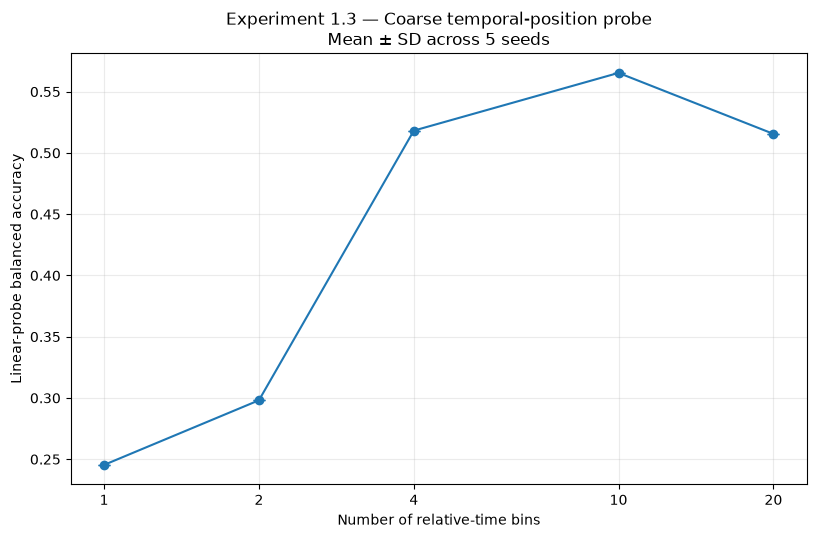

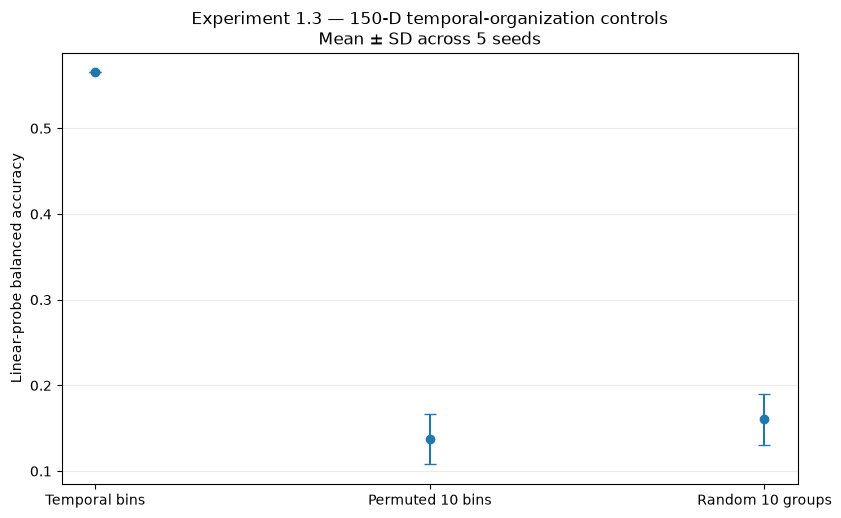

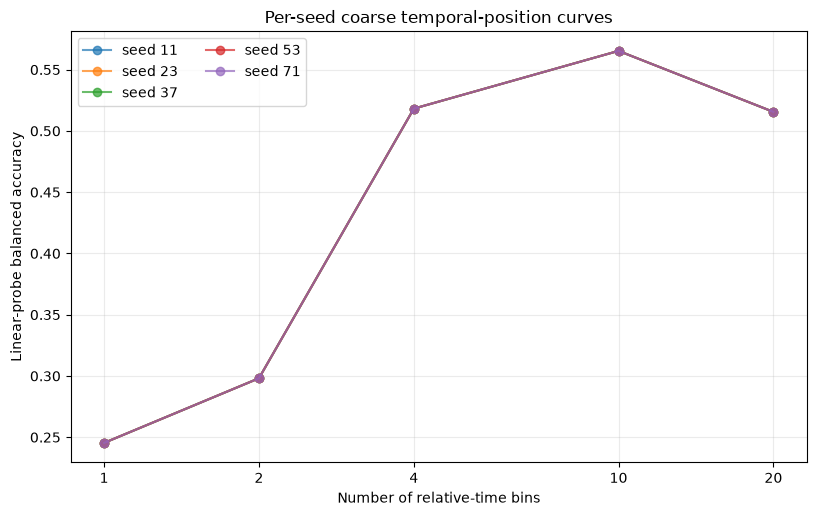

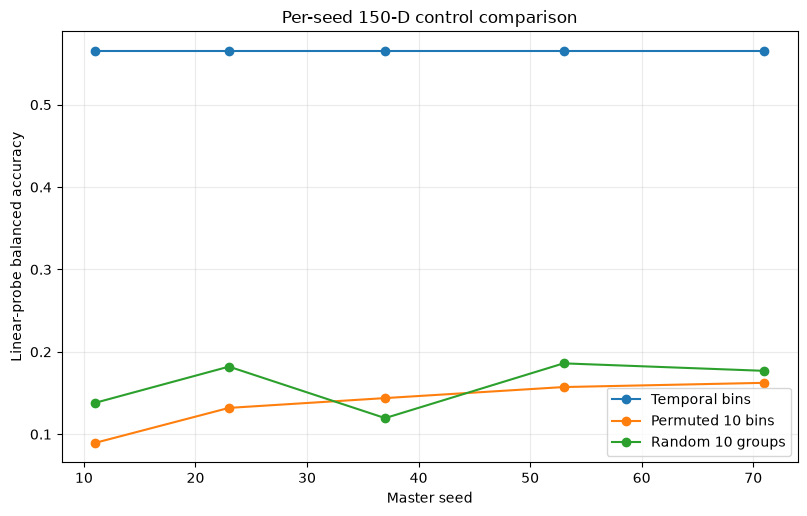

In [10]:
summary = (
    results.groupby(["condition", "n_bins", "feature_dim"], as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        sd_balanced_accuracy=("balanced_accuracy", "std"),
        mean_accuracy=("accuracy", "mean"),
        mean_macro_f1=("macro_f1", "mean"),
    )
)
summary["nominal_percent_of_gesture_per_bin"] = 100.0 / summary["n_bins"]
display(summary)

temporal_summary = summary[summary["condition"] == "temporal_bins"].copy()
temporal_results = results[results["condition"] == "temporal_bins"].copy()

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.errorbar(
    temporal_summary["n_bins"], temporal_summary["mean_balanced_accuracy"],
    yerr=temporal_summary["sd_balanced_accuracy"], marker="o", capsize=4,
)
ax.set_xscale("log", base=2)
ax.set_xticks(list(N_BINS), labels=[str(v) for v in N_BINS])
ax.set_xlabel("Number of relative-time bins")
ax.set_ylabel("Linear-probe balanced accuracy")
ax.set_title("Experiment 1.3 — Coarse temporal-position probe\nMean ± SD across 5 seeds")
ax.grid(True, alpha=0.25)
plt.show()

control_order = ("temporal_bins", "permuted_10_bins", "random_10_groups")
control_labels = {
    "temporal_bins": "Temporal bins",
    "permuted_10_bins": "Permuted 10 bins",
    "random_10_groups": "Random 10 groups",
}
control_summary = summary[
    (summary["n_bins"] == CONTROL_N_BINS)
    & summary["condition"].isin(control_order)
].copy()
control_summary["condition"] = pd.Categorical(
    control_summary["condition"], categories=control_order, ordered=True
)
control_summary = control_summary.sort_values("condition")

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.errorbar(
    np.arange(len(control_summary)),
    control_summary["mean_balanced_accuracy"],
    yerr=control_summary["sd_balanced_accuracy"],
    fmt="o", capsize=4,
)
ax.set_xticks(
    np.arange(len(control_summary)),
    labels=[control_labels[c] for c in control_summary["condition"].astype(str)],
)
ax.set_ylabel("Linear-probe balanced accuracy")
ax.set_title("Experiment 1.3 — 150-D temporal-organization controls\nMean ± SD across 5 seeds")
ax.grid(True, axis="y", alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.6))
for seed in SEEDS:
    sdf = temporal_results[temporal_results.seed == seed].sort_values("n_bins")
    ax.plot(sdf.n_bins, sdf.balanced_accuracy, marker="o", alpha=0.7, label=f"seed {seed}")
ax.set_xscale("log", base=2)
ax.set_xticks(list(N_BINS), labels=[str(v) for v in N_BINS])
ax.set_xlabel("Number of relative-time bins")
ax.set_ylabel("Linear-probe balanced accuracy")
ax.set_title("Per-seed coarse temporal-position curves")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.6))
for condition in control_order:
    sdf = results[
        (results.condition == condition) & (results.n_bins == CONTROL_N_BINS)
    ].sort_values("seed")
    ax.plot(
        sdf.seed, sdf.balanced_accuracy, marker="o",
        label=control_labels[condition],
    )
ax.set_xlabel("Master seed")
ax.set_ylabel("Linear-probe balanced accuracy")
ax.set_title("Per-seed 150-D control comparison")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

## Interpretation guide

- **1 bin already strong:** global per-channel weighted event totals explain a large part of the task; elaborate sequence memory may not be necessary.
- **2–4 bins give a large jump:** coarse early/middle/late trajectory position is highly informative.
- **10–20 bins continue improving substantially:** finer temporal localization matters and should be compared with Experiment 1.2's block-preservation curve.
- **Temporal 10-bin features outperform both 150-D controls:** this supports temporal organization, rather than feature dimensionality alone, as the source of the gain.
- **Permuted 10 bins remain strong:** bin identity may not be essential, so the result may be driven by aggregate channel statistics or the 150-D representation.
- **Random 10 groups remain strong:** temporal adjacency is not required by this probe; if both controls collapse, the evidence for relative temporal position is stronger.
- **Linear bin probe stays weak while Event-CNN-L is strong:** discriminative information is likely in local temporal patterns/interactions that simple temporal histograms cannot represent.

Experiment 1.3 is intentionally simple. Its role is to establish a low-capacity, interpretable temporal-position baseline before attributing gains to multi-timescale SNN dynamics.

## Review / audit checklist

Before treating the figure as scientific evidence, verify:

1. The two configured roots are the intended Action 0 and Action 1 *combination* datasets.
2. Sampling rate, target lengths, encoder identity, and right-padding contracts pass repository validation.
3. The same five master seeds are used across all Phase-A notebooks.
4. Within a given seed, the train/val/test users do not change across temporal conditions.
5. Every bin-count and control condition fits a fresh linear probe on the same seed-specific train/test cohort.
6. Only the valid prefix is transformed; padding remains zero.
7. All 15 event channels remain aligned within each temporal bin or random group.
8. Mean ± SD is interpreted together with the per-seed curves; a conclusion should not be driven by one split.
9. The temporal-block curve is an information-ablation curve for this decoder, not a literal neuronal memory constant. It should guide, not mechanically dictate, later `tau_syn` or recurrence choices.
